In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind, f_oneway

## Does Economic Inequality Predict Happiness? 
#### A Data‑Driven Exploration of Global Well‑Being

Researcher: Mihail Nemtserov \
Date: April 2026

### Introduction
Happiness is something everyone cares about, yet it often feels mysterious. Some countries seem to consistently report higher life satisfaction, while others struggle year after year. It’s easy to assume that wealth alone explains the difference, but the story is rarely that simple. Happiness is often treated as something personal and subjective, yet it is measured every year on a global scale. Countries are ranked, compared, and analyzed based on how satisfied their citizens feel with their lives. In recent years, more attention has been drawn to the idea that economic inequality — the gap between the richest and poorest people — might play a role in how happy a society feels. The idea that large gaps between the rich and the poor continues to be discussed as one of the major forces shaping social well‑being. 

The idea sounds intuitive. When opportunities are unevenly distributed, trust can be weakened, stress can rise, and people may feel that life is less fair. But is this actually reflected in the data? Or is inequality just one of many factors that shape well‑being?

**Does economic inequality predict how happy a country is — and how does it compare to other development factors?**

Three large and respected sources of real‑world data are used in this project. The World Happiness Report (2005–2024), The World Bank’s Gini Index dataset, and the World Bank’s World Development Indicators (WDI) datasets are brought together in attempt to give an answer to this simple but meaningful question.
  
The goal of this project is not only to look for statistical relationships, but also to tell a clear and accessible story about what the data suggests. Patterns across regions will be examined, trends over time will be visualized, and several hypotheses will be tested to see whether inequality truly stands out as a key factor in national well‑being.

In the end, the hope is that the findings will offer a clearer picture of how fairness, opportunity, and economic balance might shape the emotional landscape of societies around the world — and why this matters for all of us.

### Problem Formulation & Methodology
Several guiding questions shape this investigation:

- Do countries with higher inequality tend to report lower happiness?

- Are certain regions more affected by inequality than others?

- Does economic prosperity or development change the relationship between inequality and happiness?

The project aims to translate a broad social question into a structured, data‑driven analysis. The hope is that the findings will offer a clearer understanding of how fairness, opportunity, and economic conditions might influence the emotional well‑being of entire societies.

The analysis begins with data cleaning and preparation. Country names are standardized, years are aligned, and only observations with valid values for the key variables are retained.

Once the datasets are merged, exploratory data analysis (EDA) is conducted to understand distributions, identify regional patterns, and visualize trends over time. Correlation analysis is used to examine how happiness relates to inequality and development indicators. Group comparisons help reveal whether certain regions experience stronger inequality–happiness relationships than others.

To test the guiding hypotheses, statistical methods such as regression analysis are applied. These models allow the relationship between inequality and happiness to be examined both on its own and while controlling for development factors like GDP, education, health, and inflation. Temporal comparisons are also made to assess whether the strength of these relationships changes across years.

### Hypotheses
To explore how inequality and happiness might be connected, three core hypotheses are formed. These are designed to guide the analysis in a clear and manageable way, while still capturing the most important aspects of the topic.

##### Hypothesis 1 — Inequality and Happiness
*This hypothesis examines whether inequality and well‑being move in opposite directions across countries.* 

**H0**:  There is no relationship between the Gini Index and the Happiness (Ladder) Score.\
**H1**:  Higher Gini Index values are associated with lower Happiness Scores.

##### Hypothesis 2 — High vs Low Inequality Groups
*This hypothesis tests whether countries with high inequality differ in happiness compared to countries with low inequality.* 

**H0**:  Mean happiness is the same in high‑inequality and low‑inequality countries.\
**H1**:  Mean happiness differs between high‑inequality and low‑inequality countries.

##### Hypothesis 3 — The Role of Development Factors
*This hypothesis tests whether inequality matters more or less depending on a country’s economic and social conditions.* 

**H0**:  Development indicators (GDP, education, health expenditure, inflation, urbanization) do not influence the relationship between inequality and happiness.\
**H1**:  Development indicators influence the relationship between inequality and happiness.




### Data Description & Data Collection
This project uses three complementary datasets that together provide a broad view of national well‑being, economic inequality, and development conditions. Each dataset contributes a different dimension of information, allowing the analysis to explore how happiness relates to both inequality and wider economic factors.
The data collection process involves obtaining the three datasets from publicly available and reputable sources, followed by preparing them for analysis through cleaning, filtering, and merging.

A sample of each dataset is displayed below for illustrative purposes.

#### 1. World Happiness Report (2005–2024) 
The World Happiness Report (WHR) provides annual measurements of subjective well‑being for countries around the world. The main variable used in this project is the *Ladder Score*, which reflects how people rate their overall life satisfaction on a scale from 0 to 10. Additional WHR indicators such as GDP per capita, social support, life expectancy, freedom, and perceptions of corruption are included as contextual variables. The dataset covers the years 2005–2024, although availability varies by country.
The WHR dataset is downloaded from Kaggle, where it is provided in a clean, tabular format. The file includes yearly happiness scores and supporting indicators. After loading the data, column names are standardized, and only the variables relevant to the analysis are retained. The dataset is then filtered to include only country‑level observations.



In [2]:
whr = pd.read_csv(
    "Data/raw/World-happiness-report-updated_2024.csv",
    encoding="latin1",
)
whr.head()

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.164,0.882,0.414,0.258
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.187,0.850,0.481,0.237
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.118,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.160,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.234,0.776,0.614,0.268


#### 2. Gini Index Dataset (World Bank)
The *Gini Index* is one of the most widely used measures of income inequality. It ranges from 0 (perfect equality) to 100 (maximum inequality). The version used in this project comes from a cleaned Kaggle compilation based on World Bank data, providing a long‑format structure with country‑year observations. This dataset offers broad coverage across regions and decades, making it suitable for comparing inequality levels over time.

The *Gini Index* data is sourced from a Kaggle dataset that compiles World Bank inequality statistics into a long‑format structure. This version is chosen because it is already cleaned, consistently formatted, and easier to merge with other datasets than the raw World Bank files. After loading the data, country names and years are checked for consistency with the WHR dataset.

In [3]:
gini = pd.read_csv("Data/raw/gini_by_country.csv")
gini.head()

,country_code,country_name,year,value
0,AGO,Angola,2000,52.0
1,AGO,Angola,2008,42.7
2,AGO,Angola,2018,51.3
3,ALB,Albania,1996,27.0
4,ALB,Albania,2002,31.7


#### 3. World Development Indicators (WDI)
To capture broader economic and social conditions, several indicators are taken from the World Bank’s World Development Indicators dataset. These include:

- GDP (current US$) — a measure of economic size
- Government expenditure on education (% of GDP) — a proxy for investment in human capital
- Government health expenditure (% of GDP) — reflecting national health investment
- Inflation (annual %) — capturing macroeconomic stability
- Urban population (%) — calculated from population and rural population values

In [4]:
wdi_indicators = pd.read_csv("Data/raw/wdi-indicators-5.csv")
wdi_indicators

,Indicator,Column in Dataset,How It Relates to the Analysis
0,GDP (current US$),GDP_current_US,Measures the size of a country’s economy. Used...
1,Education Expenditure (% of GDP),government_expenditure_on_education%,Captures national investment in human capital....
2,Health Expenditure (% of GDP),government_health_expenditure%,Reflects investment in public health systems. ...
3,Inflation (annual %),inflation_annual%,Indicates macroeconomic stability. High inflat...
4,Urban Population (%),urban_population% (computed from population an...,Represents the share of people living in urban...


These variables provide essential context for understanding how development conditions may influence or moderate the relationship between inequality and happiness.
Together, the three datasets form a unified panel of country‑year observations that combine subjective well‑being, inequality, and development indicators into a single analytical framework.
The WDI dataset is also obtained from Kaggle, where it is provided as a consolidated table containing selected economic and social indicators. From this dataset, five variables are extracted: GDP, education expenditure, health expenditure, inflation, and population measures. Urban population share is computed directly from the population and rural population columns. The dataset is then filtered to keep only the columns needed for the analysis.

In [5]:
wdi = pd.read_csv(
    "Data/raw/world_bank_development_indicators.csv",
    encoding="latin1",
)
wdi.head()

,country,date,agricultural_land%,forest_land%,land_area,avg_precipitation,trade_in_services%,control_of_corruption_estimate,control_of_corruption_std,access_to_electricity%,...,multidimensional_poverty_headcount_ratio%,gini_index,birth_rate,death_rate,life_expectancy_at_birth,population,rural_population,voice_and_accountability_estimate,voice_and_accountability_std,intentional_homicides
0,Afghanistan,1960-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,50.340,31.921,32.535,8622466.0,7898093.0,NaN,NaN,NaN
1,Afghanistan,1961-01-01,57.878356,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.443,31.349,33.068,8790140.0,8026804.0,NaN,NaN,NaN
2,Afghanistan,1962-01-01,57.955016,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.570,30.845,33.547,8969047.0,8163985.0,NaN,NaN,NaN
3,Afghanistan,1963-01-01,58.031676,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.703,30.359,34.016,9157465.0,8308019.0,NaN,NaN,NaN
4,Afghanistan,1964-01-01,58.116002,NaN,652230.0,327.0,NaN,NaN,NaN,NaN,...,NaN,NaN,50.831,29.867,34.494,9355514.0,8458694.0,NaN,NaN,NaN


#### Merging the Datasets
Once each dataset is cleaned and standardized, they are merged using country and year as the common keys. Country names are harmonized across sources, and years are converted to a consistent numeric format. Observations with missing values in the key variables are handled appropriately to ensure a reliable final dataset.

The result is a unified analytical dataset that brings together happiness, inequality, and development indicators for a wide range of countries and years, forming the foundation for the exploratory and statistical analysis that follows.

### Data Cleaning & Preparation
This section describes the cleaning and preparation steps applied to each dataset before merging them into a unified analytical table. The goal is to ensure consistent country names, aligned years, and complete values for the variables used in the analysis.

#### 1. World Happiness Report (WHR)
##### Initial inspection of the basic structure

In [6]:
whr.shape # return number of rows and columns

(2363, 11)

In [7]:
whr.info() # return column types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2363 non-null   object 
 1   year                              2363 non-null   int64  
 2   Life Ladder                       2363 non-null   float64
 3   Log GDP per capita                2335 non-null   float64
 4   Social support                    2350 non-null   float64
 5   Healthy life expectancy at birth  2300 non-null   float64
 6   Freedom to make life choices      2327 non-null   float64
 7   Generosity                        2282 non-null   float64
 8   Perceptions of corruption         2238 non-null   float64
 9   Positive affect                   2339 non-null   float64
 10  Negative affect                   2347 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 203.2+ KB


In [8]:
whr.columns # return list of column names

Index(['Country name', 'year', 'Life Ladder', 'Log GDP per capita',
       'Social support', 'Healthy life expectancy at birth',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Positive affect', 'Negative affect'],
      dtype='object')

In [9]:
whr.isna().sum() # check for missing values

Country name                          0
year                                  0
Life Ladder                           0
Log GDP per capita                   28
Social support                       13
Healthy life expectancy at birth     63
Freedom to make life choices         36
Generosity                           81
Perceptions of corruption           125
Positive affect                      24
Negative affect                      16
dtype: int64

##### Clean and normalize column names

In [10]:
# remove all non-printable characters and normalize spaces
def clean_col(col):
    col = re.sub(r'[^\x20-\x7E]+', '', col) 
    col = col.strip().replace("  ", " ")  
    return col

In [11]:
whr.columns = [clean_col(c) for c in whr.columns]

for col in whr.columns:
    print(repr(col))

'Country name'
'year'
'Life Ladder'
'Log GDP per capita'
'Social support'
'Healthy life expectancy at birth'
'Freedom to make life choices'
'Generosity'
'Perceptions of corruption'
'Positive affect'
'Negative affect'


##### Rename and select key columns needed for analysis

In [12]:
# rename important columns
whr = whr.rename(columns={
    "Life Ladder": "Happiness",
    "Log GDP per capita": "GDP_per_capita",
    "Healthy life expectancy at birth": "Life_expectancy",        
    "Freedom to make life choices": "Freedom",
    "Perceptions of corruption": "Corruption"
})

In [13]:
# keep important columns
whr_use = whr[[
    "Country name",
    "year",
    "Happiness",
    "GDP_per_capita",
    "Social support",        
    "Life_expectancy",
    "Freedom",
    "Corruption"
]].copy()

##### Finalize column names for merging

In [14]:
whr_use = whr_use.rename(columns={
    "Country name": "Country",
    "Social support": "Social_support"
})

##### Now WHR subset has standard names:
Country | year | Happiness | GDP_per_capita | Social_support | Life_expectancy | Freedom | Corruption

In [15]:
# confirm year is numeric and consistent for merging
whr_use["year"] = whr_use["year"].astype("Int64") 

##### Handle and check missing values in key columns

In [16]:
# remove rows where the main outcome "Happiness" is missing
whr_use = whr_use.dropna(subset=["Happiness"]) 

In [17]:
# check for missing values
whr_use.isna().sum() 

Country              0
year                 0
Happiness            0
GDP_per_capita      28
Social_support      13
Life_expectancy     63
Freedom             36
Corruption         125
dtype: int64

##### Check cleaned WHR dataset

In [18]:
whr_use.shape
whr_use.info()
whr_use.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          2363 non-null   object 
 1   year             2363 non-null   Int64  
 2   Happiness        2363 non-null   float64
 3   GDP_per_capita   2335 non-null   float64
 4   Social_support   2350 non-null   float64
 5   Life_expectancy  2300 non-null   float64
 6   Freedom          2327 non-null   float64
 7   Corruption       2238 non-null   float64
dtypes: Int64(1), float64(6), object(1)
memory usage: 150.1+ KB


,Country,year,Happiness,GDP_per_capita,Social_support,Life_expectancy,Freedom,Corruption
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.882
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.850
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.707
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.731
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.776


#### 2. Gini Index
##### Initial inspection of the basic structure

In [19]:
# return number of rows and columns
gini.shape 

(1896, 4)

In [20]:
# return column types and non-null counts
gini.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  1896 non-null   object 
 1   country_name  1896 non-null   object 
 2   year          1896 non-null   int64  
 3   value         1896 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 59.4+ KB


In [21]:
# return list of column names
gini.columns 

Index(['country_code', 'country_name', 'year', 'value'], dtype='object')

In [22]:
 # check for missing values
gini.isna().sum()

country_code    0
country_name    0
year            0
value           0
dtype: int64

##### Clean and normalize column names

In [23]:
# remove non-printable chars and normalize spaces
def clean_col(col):
    col = re.sub(r'[^\x20-\x7E]+', '', col)  
    col = col.strip().replace("  ", " ")     
    return col

In [24]:
# provide correct rename mapping
gini.columns = [clean_col(c) for c in gini.columns]

for col in gini.columns:                   
    print(repr(col))

'country_code'
'country_name'
'year'
'value'


##### Standardize and rename key column names

In [25]:
# rename columns to match WHR and WDI
gini = gini.rename(columns={
    "Country": "Country",
    "Country Name": "Country",      
    "Year": "year",
    "Gini index": "Gini",
    "GINI index": "Gini"           
})                                 

In [26]:
# rename columns to match WHR and WDI
gini = gini.rename(columns={
    "country_name": "Country",
    "value": "Gini"               
})

##### Now Gini Index subset has standard names:
country_code | Country | year | Gini

In [27]:
# make sure year is intiger and consistent for merging
gini["year"] = gini["year"].astype("Int64")  

In [28]:
# inspect unique year values
gini["year"].unique()[:20]  

<IntegerArray>
[2000, 2008, 2018, 1996, 2002, 2005, 2012, 2014, 2015, 2016, 2017, 2019, 2013,
 1980, 1986, 1987, 1991, 1992, 1993, 1994]
Length: 20, dtype: Int64

In [29]:
# confirm gini is numeric and consistent for merging
gini["Gini"] = pd.to_numeric(gini["Gini"], errors="coerce") 

##### Keep only the columns needed for analysis

In [30]:
gini_use = gini[["Country", "year", "Gini"]].copy()

##### Handle and check missing values in key columns

In [31]:
gini_use = gini_use.dropna(subset=["Gini"])

##### Check cleaned Gini Index dataset

In [32]:
gini_use.head()
gini_use.info()
gini_use.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  1896 non-null   object 
 1   year     1896 non-null   Int64  
 2   Gini     1896 non-null   float64
dtypes: Int64(1), float64(1), object(1)
memory usage: 46.4+ KB


,year,Gini
count,1896.0,1896.000000
mean,2006.275844,38.179325
std,9.348789,9.077638
min,1967.0,20.200000
25%,2000.75,31.200000
50%,2008.0,36.100000
75%,2014.0,44.100000
max,2021.0,65.800000


#### 3. World Development Indicators (WDI)
##### Initial inspection of the basic structure

In [33]:
# return number of rows and columns
wdi.shape 

(17272, 50)

In [34]:
# return column types and non-null counts
wdi.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17272 entries, 0 to 17271
Data columns (total 50 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    17272 non-null  object 
 1   date                                       17272 non-null  object 
 2   agricultural_land%                         14714 non-null  float64
 3   forest_land%                               8176 non-null   float64
 4   land_area                                  14930 non-null  float64
 5   avg_precipitation                          10086 non-null  float64
 6   trade_in_services%                         9195 non-null   float64
 7   control_of_corruption_estimate             4783 non-null   float64
 8   control_of_corruption_std                  4783 non-null   float64
 9   access_to_electricity%                     7348 non-null   float64
 10  renewvable_energy_cons

In [35]:
# return list of column names
wdi.columns 

Index(['country', 'date', 'agricultural_land%', 'forest_land%', 'land_area',
       'avg_precipitation', 'trade_in_services%',
       'control_of_corruption_estimate', 'control_of_corruption_std',
       'access_to_electricity%', 'renewvable_energy_consumption%',
       'electric_power_consumption', 'CO2_emisions',
       'other_greenhouse_emisions', 'population_density', 'inflation_annual%',
       'real_interest_rate', 'risk_premium_on_lending',
       'research_and_development_expenditure%', 'central_goverment_debt%',
       'tax_revenue%', 'expense%', 'goverment_effectiveness_estimate',
       'goverment_effectiveness_std', 'human_capital_index', 'doing_business',
       'time_to_get_operation_license', 'statistical_performance_indicators',
       'individuals_using_internet%', 'logistic_performance_index',
       'military_expenditure%', 'GDP_current_US',
       'political_stability_estimate', 'political_stability_std',
       'rule_of_law_estimate', 'rule_of_law_std',
       'reg

In [36]:
# check for missing values
wdi.isna().sum() 

country                                          0
date                                             0
agricultural_land%                            2558
forest_land%                                  9096
land_area                                     2342
avg_precipitation                             7186
trade_in_services%                            8077
control_of_corruption_estimate               12489
control_of_corruption_std                    12489
access_to_electricity%                        9924
renewvable_energy_consumption%                9196
electric_power_consumption                    9482
CO2_emisions                                  9864
other_greenhouse_emisions                     9864
population_density                            2371
inflation_annual%                             6484
real_interest_rate                           12856
risk_premium_on_lending                      14902
research_and_development_expenditure%        14383
central_goverment_debt%        

##### Convert date to numerical value

In [37]:
# display date format
wdi["date"].head(20).tolist()  

['1960-01-01',
 '1961-01-01',
 '1962-01-01',
 '1963-01-01',
 '1964-01-01',
 '1965-01-01',
 '1966-01-01',
 '1967-01-01',
 '1968-01-01',
 '1969-01-01',
 '1970-01-01',
 '1971-01-01',
 '1972-01-01',
 '1973-01-01',
 '1974-01-01',
 '1975-01-01',
 '1976-01-01',
 '1977-01-01',
 '1978-01-01',
 '1979-01-01']

In [38]:
# convert date to year
wdi["year"] = pd.to_datetime(wdi["date"], errors="coerce").dt.year 

In [39]:
 # convert intiger type
wdi["year"] = wdi["year"].astype("Int64")  

In [40]:
# check result
wdi["year"].isna().sum(), wdi["year"].unique()[:20] 

(np.int64(0),
 <IntegerArray>
 [1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972,
  1973, 1974, 1975, 1976, 1977, 1978, 1979]
 Length: 20, dtype: Int64)

##### Standardize and rename key column names

In [41]:
wdi = wdi.rename(columns={
    "country": "Country",
    "GDP_current_US": "GDP",
    "government_expenditure_on_education%": "Education",
    "government_health_expenditure%": "Health",
    "inflation_annual%": "Inflation"
})

##### Ensure numeric types

In [42]:
# confirm year is numeric
wdi["year"] = pd.to_numeric(wdi["year"], errors="coerce").astype("Int64")

In [43]:
# convert indicator columns to numeric
numeric_cols = ["GDP", "Education", "Health", "Inflation",
                "population", "rural_population"]

for col in numeric_cols:
    wdi[col] = pd.to_numeric(wdi[col], errors="coerce")    

##### Calculate urban population share

In [44]:
# calculate urban_population% from population and rural population
wdi["urban_population%"] = 100 * (
    1 - (wdi["rural_population"] / wdi["population"])
)                                                      

In [45]:
# rename urban population column
wdi = wdi.rename(columns={
    "urban_population%": "Urban Population"
})

##### Keep only the columns needed for analysis

In [46]:
wdi_use = wdi[[
    "Country",
    "year",
    "GDP",
    "Education",
    "Health",
    "Inflation",
    "Urban Population"
]].copy()

##### Drop rows where "Country" or "year" is missing

In [47]:
# drop rows where "Country" or "year" is missing
wdi_use = wdi_use.dropna(subset=["Country", "year"]) 

##### Inspect missing values

In [48]:
# inspect missing values
wdi_use.isna().sum()

Country                 0
year                    0
GDP                  4074
Education           11165
Health              12334
Inflation            6484
Urban Population      733
dtype: int64

##### Check cleaned WDI dataset

In [49]:
wdi_use.info()
wdi_use.shape
wdi_use.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17272 entries, 0 to 17271
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           17272 non-null  object 
 1   year              17272 non-null  Int64  
 2   GDP               13198 non-null  float64
 3   Education         6107 non-null   float64
 4   Health            4938 non-null   float64
 5   Inflation         10788 non-null  float64
 6   Urban Population  16539 non-null  float64
dtypes: Int64(1), float64(5), object(1)
memory usage: 961.6+ KB


,year,GDP,Education,Health,Inflation,Urban Population
count,17272.0,1.319800e+04,6107.000000,4938.000000,10788.000000,16539.000000
mean,1991.69384,1.223794e+12,4.296010,3.226953,20.044991,50.227497
std,18.441741,5.453493e+12,1.808388,2.268737,291.284618,24.788533
min,1960.0,8.824744e+06,0.000000,0.062211,-17.640424,2.076983
25%,1976.0,2.434830e+09,3.131605,1.522687,2.389467,29.964535
50%,1992.0,1.785744e+10,4.138330,2.638003,4.918952,48.756001
75%,2008.0,2.264476e+11,5.188705,4.409181,9.724428,69.568998
max,2023.0,1.008796e+14,44.333981,22.254263,23773.131774,100.000000


### Merging datasets
##### Merge all three datasets on the common keys "Country" and "year" into a single analysis dataframe

##### 1. First merge: WHR dataset & Gini Index dataset
Starting with an inner merge to keep only country – year pairs that exist in both

In [50]:
# merge WHR and Gini on Country + year
# only rows where both WHR and Gini exist
whr_gini = pd.merge(
    whr_use,                            
    gini_use,                           
    on=["Country", "year"],                  
    how="inner"
)

##### Summary of the WHR_Gini merged dataset

In [51]:
whr_gini.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          908 non-null    object 
 1   year             908 non-null    Int64  
 2   Happiness        908 non-null    float64
 3   GDP_per_capita   907 non-null    float64
 4   Social_support   905 non-null    float64
 5   Life_expectancy  899 non-null    float64
 6   Freedom          902 non-null    float64
 7   Corruption       885 non-null    float64
 8   Gini             908 non-null    float64
dtypes: Int64(1), float64(7), object(1)
memory usage: 64.9+ KB


In [52]:
whr_gini.head()

,Country,year,Happiness,GDP_per_capita,Social_support,Life_expectancy,Freedom,Corruption,Gini
0,Albania,2012,5.510,9.326,0.785,68.160,0.602,0.848,29.0
1,Albania,2014,4.814,9.358,0.626,68.720,0.735,0.883,34.6
2,Albania,2015,4.607,9.382,0.639,69.000,0.704,0.885,32.8
3,Albania,2016,4.511,9.417,0.638,69.025,0.730,0.901,33.7
4,Albania,2017,4.640,9.455,0.638,69.050,0.750,0.876,33.1


In [53]:
whr_gini[["Country", "year"]].drop_duplicates().shape

(908, 2)

##### 2. Second merge: WHR_Gini dataset & WDI dataset
Bringing in the WDI indicators

In [54]:
wdi_indicators = pd.read_csv("Data/raw/wdi-indicators-5.csv")
wdi_indicators

,Indicator,Column in Dataset,How It Relates to the Analysis
0,GDP (current US$),GDP_current_US,Measures the size of a country’s economy. Used...
1,Education Expenditure (% of GDP),government_expenditure_on_education%,Captures national investment in human capital....
2,Health Expenditure (% of GDP),government_health_expenditure%,Reflects investment in public health systems. ...
3,Inflation (annual %),inflation_annual%,Indicates macroeconomic stability. High inflat...
4,Urban Population (%),urban_population% (computed from population an...,Represents the share of people living in urban...


In [55]:
# keeps only country–year pairs present in all three datasets
full_df = pd.merge(
    whr_gini,                      
    wdi_use,
    on=["Country", "year"],
    how="inner"
)

##### Summary of the three merged datasets as full data frame

In [56]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           908 non-null    object 
 1   year              908 non-null    Int64  
 2   Happiness         908 non-null    float64
 3   GDP_per_capita    907 non-null    float64
 4   Social_support    905 non-null    float64
 5   Life_expectancy   899 non-null    float64
 6   Freedom           902 non-null    float64
 7   Corruption        885 non-null    float64
 8   Gini              908 non-null    float64
 9   GDP               900 non-null    float64
 10  Education         804 non-null    float64
 11  Health            890 non-null    float64
 12  Inflation         887 non-null    float64
 13  Urban Population  892 non-null    float64
dtypes: Int64(1), float64(12), object(1)
memory usage: 100.3+ KB


In [57]:
full_df.head()

,Country,year,Happiness,GDP_per_capita,Social_support,Life_expectancy,Freedom,Corruption,Gini,GDP,Education,Health,Inflation,Urban Population
0,Albania,2012,5.510,9.326,0.785,68.160,0.602,0.848,29.0,1.231983e+10,3.309061,2.455187,2.031593,54.330005
1,Albania,2014,4.814,9.358,0.626,68.720,0.735,0.883,34.6,1.322815e+10,3.216967,2.593627,1.625865,56.422995
2,Albania,2015,4.607,9.382,0.639,69.000,0.704,0.885,32.8,1.138685e+10,3.437970,2.731354,1.896174,57.434001
3,Albania,2016,4.511,9.417,0.638,69.025,0.730,0.901,33.7,1.186120e+10,3.962090,2.803707,1.275432,58.421001
4,Albania,2017,4.640,9.455,0.638,69.050,0.750,0.876,33.1,1.301973e+10,3.611720,2.675080,1.986661,59.383001


In [58]:
full_df[["Country", "year"]].drop_duplicates().shape

(908, 2)

##### Check for duplicates on Country - year base

In [59]:
dups = full_df.duplicated(subset=["Country", "year"], keep=False)
full_df[dups].sort_values(["Country", "year"]).head()

,Country,year,Happiness,GDP_per_capita,Social_support,Life_expectancy,Freedom,Corruption,Gini,GDP,Education,Health,Inflation,Urban Population


In [60]:
# check for duplicates
dups.sum() 

np.int64(0)

##### Inspection for missing values

In [61]:
# check for missing values
full_df.isna().sum() 

Country               0
year                  0
Happiness             0
GDP_per_capita        1
Social_support        3
Life_expectancy       9
Freedom               6
Corruption           23
Gini                  0
GDP                   8
Education           104
Health               18
Inflation            21
Urban Population     16
dtype: int64

##### Conclusion: Core indicators have fully complete data, missing data is in secondary indicators.

##### The common compromise
Since there are missing values in the merged dataset it is decided to keep rows where core variables are complete, but allow missingness in secondary variables. This gives a large enough dataset, high‑quality core indicators and flexibility to impute or drop secondary indicators later if needed (drop missing values only when they matter for the specific model).
The full sample size for most analyses is preserved. It allows to maintain statistical power and keeps the flexibility for different models. Avoid bias from overly strict filtering and throwing away 10% of data unnecessarily.

In [62]:
key_cols = ["Happiness", "Gini", "GDP_per_capita", "GDP", "Inflation", "Urban Population"]

analysis_df = full_df.dropna(subset=key_cols).copy()


##### Summary check full new data frame

In [63]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 877 entries, 0 to 907
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           877 non-null    object 
 1   year              877 non-null    Int64  
 2   Happiness         877 non-null    float64
 3   GDP_per_capita    877 non-null    float64
 4   Social_support    874 non-null    float64
 5   Life_expectancy   877 non-null    float64
 6   Freedom           872 non-null    float64
 7   Corruption        856 non-null    float64
 8   Gini              877 non-null    float64
 9   GDP               877 non-null    float64
 10  Education         789 non-null    float64
 11  Health            876 non-null    float64
 12  Inflation         877 non-null    float64
 13  Urban Population  877 non-null    float64
dtypes: Int64(1), float64(12), object(1)
memory usage: 103.6+ KB


In [64]:
analysis_df.describe()

,year,Happiness,GDP_per_capita,Social_support,Life_expectancy,Freedom,Corruption,Gini,GDP,Education,Health,Inflation,Urban Population
count,877.0,877.000000,877.000000,874.000000,877.000000,872.000000,856.000000,877.000000,8.770000e+02,789.000000,876.000000,877.000000,877.000000
mean,2012.895097,5.898271,9.829017,0.851985,65.972651,0.767627,0.742607,36.809920,8.218213e+11,4.775398,4.402006,4.117915,66.998085
std,4.00005,1.048171,0.925865,0.101192,5.172998,0.134833,0.197143,7.918117,2.481002e+12,1.401585,2.223976,9.740007,17.253319
min,2005.0,2.694000,6.867000,0.303000,38.640000,0.315000,0.117000,24.000000,1.373000e+09,1.453420,0.437210,-4.478103,16.215997
25%,2010.0,5.132000,9.339000,0.805250,63.920000,0.676750,0.664750,30.800000,2.726089e+10,3.767920,2.723228,1.364354,56.900000
50%,2013.0,5.885000,9.924000,0.885000,66.820000,0.791000,0.804000,35.200000,1.286098e+11,4.723750,4.297738,2.691370,68.046999
75%,2016.0,6.790000,10.583000,0.923750,70.000000,0.879250,0.890000,41.800000,4.320519e+11,5.547110,6.028044,4.971486,79.764000
max,2021.0,8.019000,11.664000,0.985000,73.360000,0.971000,0.983000,63.400000,2.138098e+13,9.509760,9.276339,255.304991,98.041001


### Exploratory Data Analysis (EDA)

In [65]:
# clean definition
analysis_df = full_df.copy()

In [66]:
# clean plots
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

#### 1. Distributions

##### Histogram of Happiness
  This shows how happiness scores are spread—whether most countries cluster around the middle, skew high/low, or have outliers.

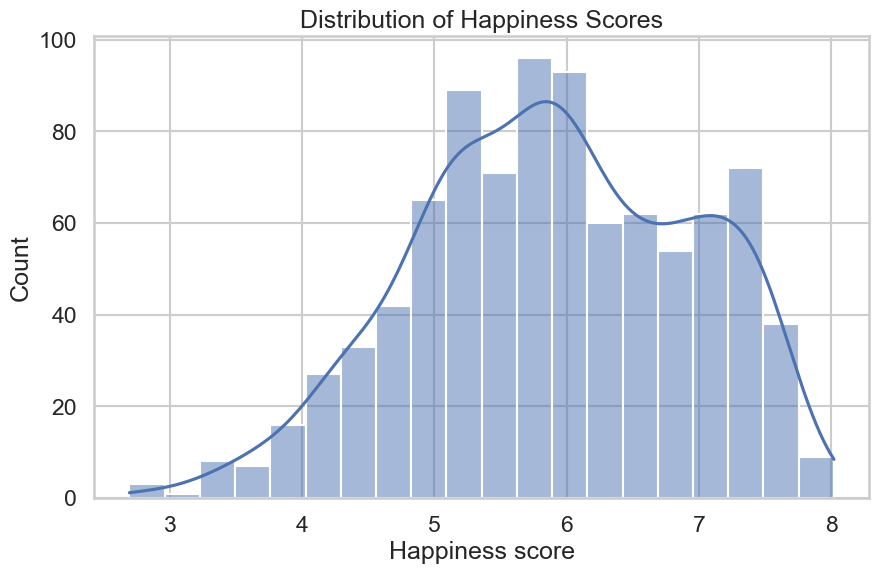

In [67]:
plt.figure()
sns.histplot(analysis_df["Happiness"], bins=20, kde=True)
plt.title("Distribution of Happiness Scores")
plt.xlabel("Happiness score")
plt.ylabel("Count")
plt.show()

##### Results:
* The distribution is centered around 5 and 6
* The distribution is slightly right‑skewed
* There are no extreme outliers
* The range is narrow 3 to 8

##### Explanation:
Most countries fall into a moderate happiness range.  
The global distribution of happiness scores peaks between 5 and 6, indicating that the majority of countries report neither very high nor very low levels of subjective well‑being.
Very unhappy countries are rare, and while some countries achieve scores above 7, these are less common.
The slight right‑skew suggests that high happiness is harder to achieve, while moderate happiness is the global norm. This aligns with the idea that once basic needs are met, further increases in happiness become progressively more difficult.

##### Histogram of Gini Index
This shows whether most countries have moderate inequality and how many are very unequal.

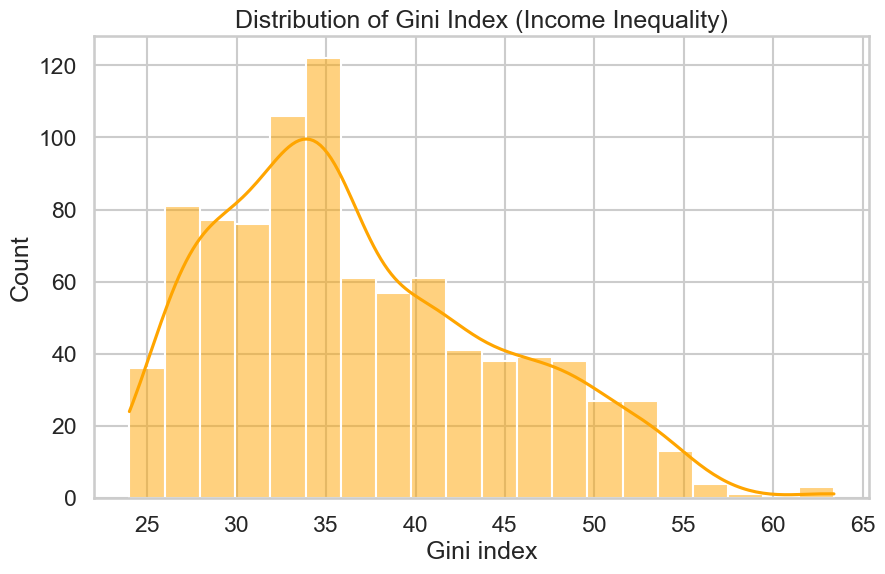

In [68]:
plt.figure()
sns.histplot(analysis_df["Gini"], bins=20, kde=True, color="orange")
plt.title("Distribution of Gini Index (Income Inequality)")
plt.xlabel("Gini index")
plt.ylabel("Count")
plt.show()

##### Results:
* Strong central peak around 33 to 38
* The distribution is slightly right‑skewed
* The range is wide 25 to 60
* No extreme outliers

##### Explanation:
Income inequality varies widely across countries, but most fall within a moderate range.  
The distribution of Gini values peaks around 35, indicating that the typical country in the dataset experiences a moderate level of inequality. Very low inequality is relatively rare, while extremely high inequality appears in a smaller but noticeable group of countries.
The slight right‑skew suggests that high inequality is less common but still significant, reflecting structural challenges in certain regions. Overall, the distribution provides a broad and realistic picture of global inequality, with enough variation to meaningfully explore how inequality relates to happiness, economic development, and social conditions.

#### 2. Scatterplots

##### Happiness vs. Gini 
Each point is a country – year where downward slope shows more inequality, lower happiness. \
If there is no clear slope shows weak or no relationship

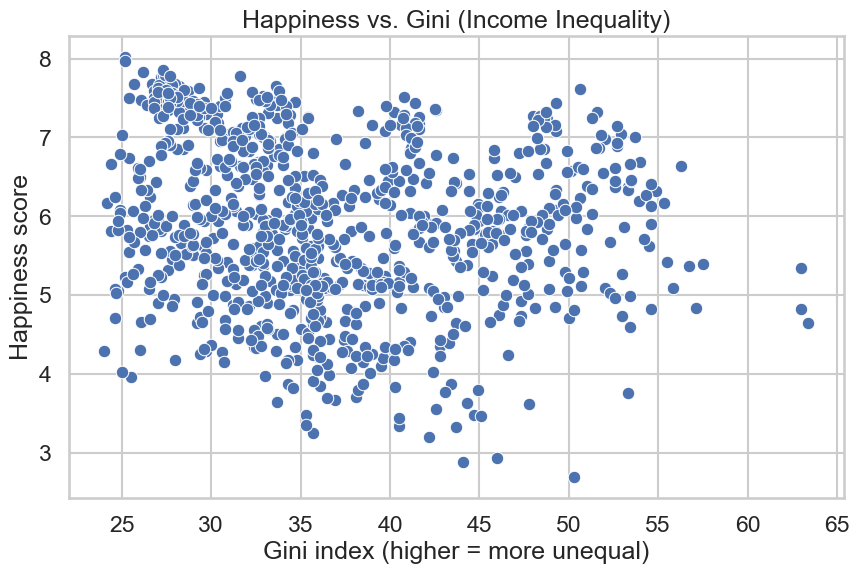

In [69]:
plt.figure()
sns.scatterplot(
    data=analysis_df,
    x="Gini",
    y="Happiness"
)
plt.title("Happiness vs. Gini (Income Inequality)")
plt.xlabel("Gini index (higher = more unequal)")
plt.ylabel("Happiness score")
plt.show()

##### Results:
* The cloud is wide and dispersed
* There is a slight downward trend
* High‑inequality countries show a wide range of happiness
* Low‑inequality countries cluster higher

##### Explanation:
The relationship between income inequality and happiness is present but modest.  
The scatterplot shows a wide cloud of points, indicating that countries with similar levels of inequality can experience very different levels of happiness.
However, a subtle downward trend is visible:
as inequality increases, average happiness tends to decline.
Low‑inequality countries (Gini 25–30) generally cluster at higher happiness levels, while high‑inequality countries show more variation — some remain moderately happy, while others fall to much lower scores.
This suggests that inequality is one factor among many shaping national well‑being. It matters, but it does not operate in isolation; economic prosperity, social support, governance, and cultural factors all play important roles in shaping how inequality translates into lived experience.

##### Happiness vs. GDP_per_capita
Check for a positive relationship whether richer countries tend to be happier, but maybe with diminishing returns.

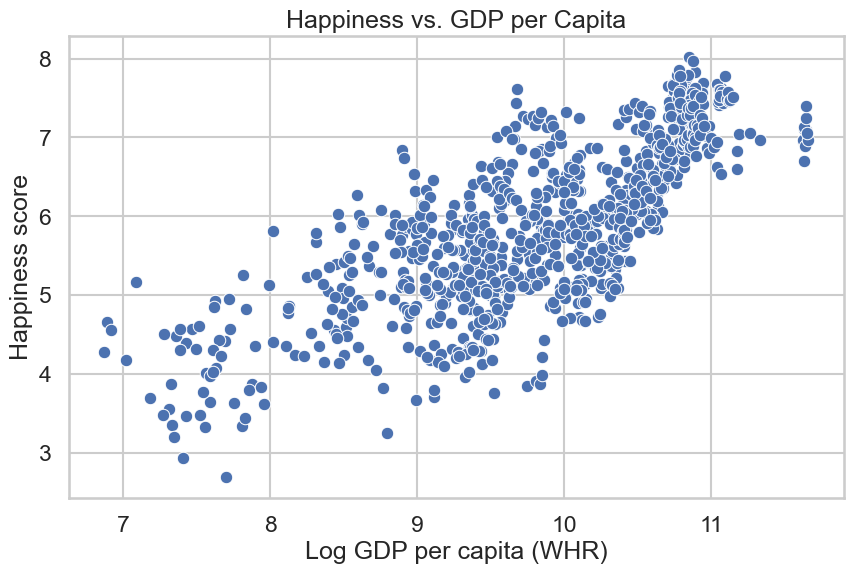

In [70]:
plt.figure()
sns.scatterplot(
    data=analysis_df,
    x="GDP_per_capita",
    y="Happiness"
)
plt.title("Happiness vs. GDP per Capita")
plt.xlabel("Log GDP per capita (WHR)")
plt.ylabel("Happiness score")
plt.show()

##### Results:
* A strong upward trend
* The relationship is nonlinear
* Low‑income countries cluster at low happiness
* High‑income countries cluster at high happiness

##### Explanation:
Economic prosperity is one of the strongest predictors of national happiness.  
The scatterplot shows a clear upward relationship between GDP per capita and happiness: richer countries consistently report higher levels of well‑being.
The pattern is nonlinear. Happiness rises sharply as countries move from low to middle income, but the gains taper off at higher income levels. This reflects the idea of diminishing marginal returns — once basic needs and security are met, additional income contributes less to overall life satisfaction.
Compared to inequality, GDP per capita shows a much tighter and more structured relationship with happiness, suggesting that economic development plays a foundational role in shaping subjective well‑being across countries.

##### Gini vs. GDP_per_capita
Check whether richer countries are systematically more or less unequal or whether inequality is high at all income levels.

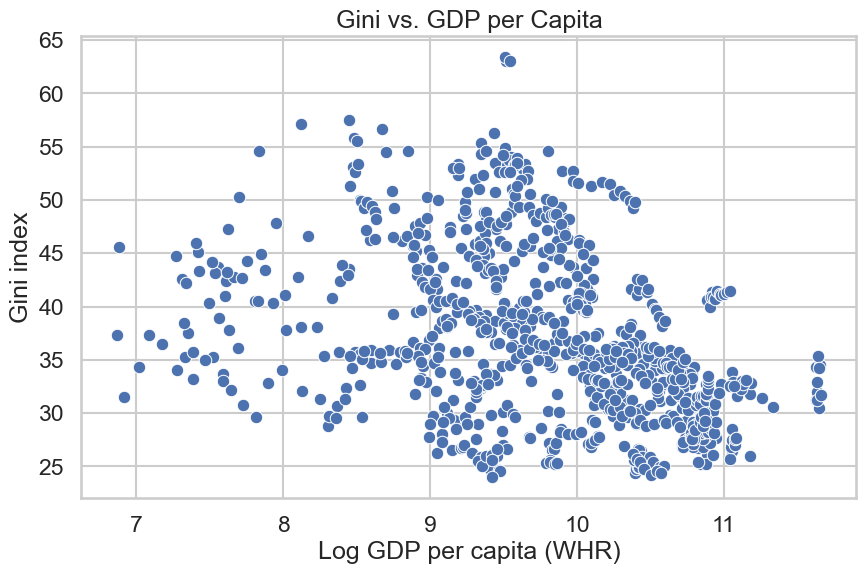

In [71]:
plt.figure()
sns.scatterplot(
    data=analysis_df,
    x="GDP_per_capita",
    y="Gini"
)
plt.title("Gini vs. GDP per Capita")
plt.xlabel("Log GDP per capita (WHR)")
plt.ylabel("Gini index")
plt.show()

##### Results:
* Clear downward trend
* The relationship is moderate, not perfect
* Low‑income countries show wide variation
* High‑income countries cluster at lower Gini

##### Explanation:
Income inequality tends to decline as countries become wealthier.  
The scatterplot shows a clear downward relationship between GDP per capita and the Gini index: richer countries generally exhibit lower levels of inequality, while poorer countries display a much wider range of inequality outcomes.
High‑income countries cluster tightly at moderate Gini levels, reflecting the role of strong institutions, social safety nets, and redistributive policies. In contrast, low‑income countries vary widely — some maintain relatively equal income distributions, while others experience extreme inequality.
This pattern suggests that economic development provides the structural capacity for more equal societies, but it does not guarantee equality on its own. Political choices, governance quality, and historical factors shape how national wealth translates into income distribution.

#### 3. Correlation heatmap

In [72]:
#select the numeric columns needed
corr_cols = [
    "Happiness", "Gini", "GDP_per_capita", "GDP",
    "Social_support", "Life_expectancy", "Freedom",
    "Corruption", "Education", "Health",
    "Inflation", "Urban Population"
]
corr_matrix = analysis_df[corr_cols].corr()

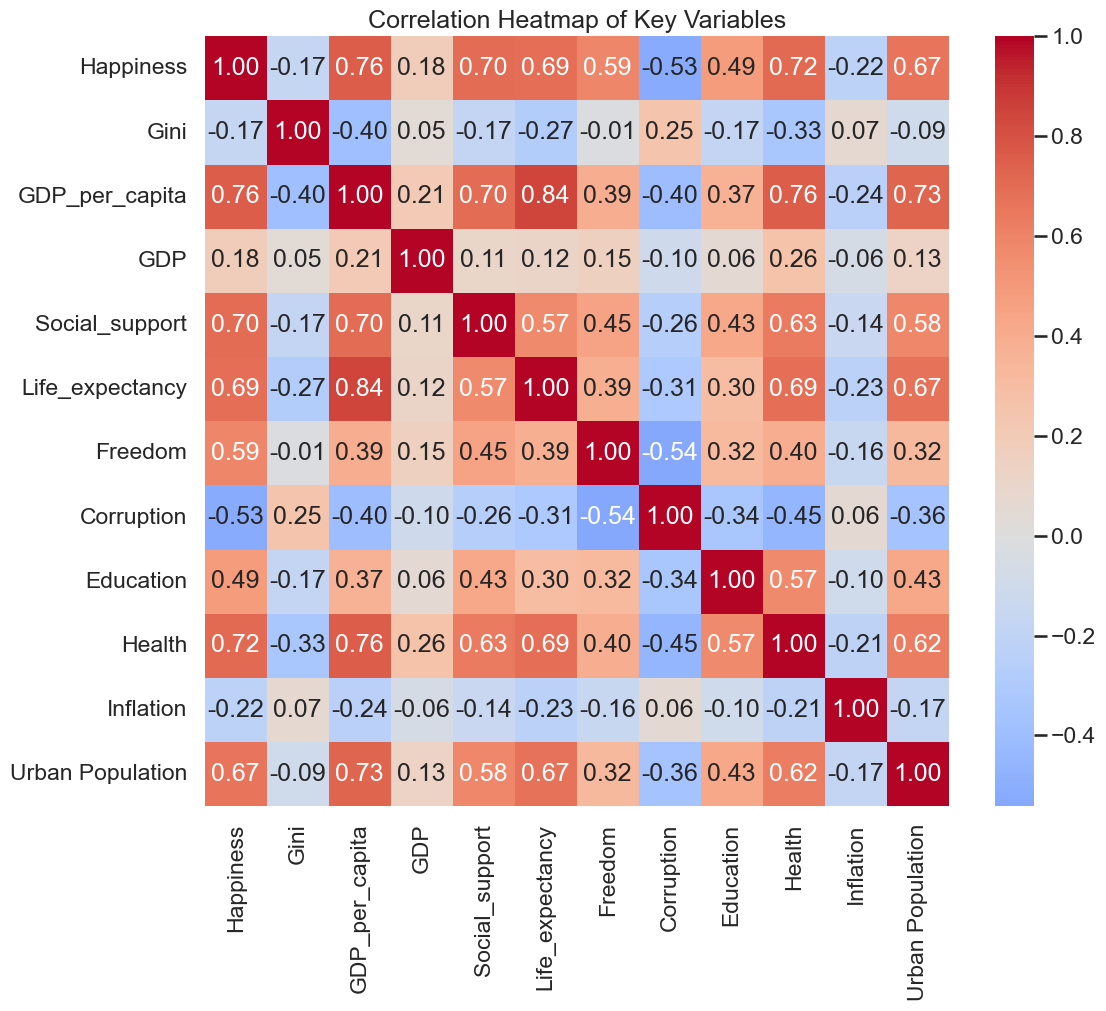

In [73]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Key Variables")
plt.show()

##### Results:
* What drives happiness most strongly:
  * GDP per capita (very strong)
  * Social_support
  * Life_expectancy
  * Freedom
  * Corruption (negative)
  * Education & Health
  * Gini (weak negative)
* Gini: what inequality is related to:
   * Gini vs GDP per capita (moderate negative)
   * Gini vs Social support (negative)
   * Gini vs Life expectancy (negative)
   * Gini vs Freedom (negative)
   * Gini vs Corruption (positive)
* GDP per capita has strong positive correlations with:
   * Life_expectancy
   * Social_support
   * Freedom
   * Health
   * Education
   * Urban Population
* Clusters:
   * Well‑being cluster (all positively correlated)
   * Inequality cluster (all negative correlated)

##### Explanation:
The correlation heatmap reveals two distinct clusters shaping global well‑being.  
Happiness is strongly associated with higher income, better social support, longer life expectancy, and greater personal freedom. These variables form a tightly connected “well-being cluster,” suggesting that prosperous, healthy, and socially cohesive societies tend to be happier.
In contrast, inequality (Gini) forms part of a separate cluster linked to higher corruption and weaker social support. Its correlation with happiness is negative but modest, indicating that inequality matters, but less than economic prosperity or social cohesion.
The heatmap highlights a broader structural pattern: economic development underpins many of the conditions that support happiness, while inequality and corruption represent barriers that erode it. This dual structure provides a clear framework for understanding the drivers of national well‑being.

### Analysis Section
This section summarizes the key statistical relationships in the dataset using correlations and simple regression models. The goal is to quantify the patterns we observed visually in the EDA.

### Hypothesis Testing

#### Hypothesis 1 - Inequality & Happiness
This hypothesis examines whether inequality and well‑being move in opposite directions across countries.
* H0: There is no relationship between the Gini Index and the Happiness (Ladder) Score.
* H1: Higher Gini Index values are associated with lower Happiness Scores.

In [74]:
# select only the indicators needed for Hypothesis 1
h1_df = analysis_df[["Happiness", "Gini"]].dropna()
h1_df.describe()

,Happiness,Gini
count,908.000000,908.000000
mean,5.892460,36.824780
std,1.039878,7.872061
min,2.694000,24.000000
25%,5.137500,30.800000
50%,5.885000,35.300000
75%,6.737000,42.050000
max,8.019000,63.400000


#### Correlation tests
The purpose of the corelation tests is to measure the strength and direction of the relationship.

##### 1. Pearson correlation (linear relationship)

In [75]:
pearson_r, pearson_p = pearsonr(h1_df["Happiness"], h1_df["Gini"])
print("Pearson r:", pearson_r)
print("Pearson p-value:", pearson_p)

Pearson r: -0.1670890425960684
Pearson p-value: 4.114067132893235e-07


##### 2. Spearman correlation (monotonic relationship)

In [76]:
spearman_r, spearman_p = spearmanr(h1_df["Happiness"], h1_df["Gini"])
print("Spearman r:", spearman_r)
print("Spearman p-value:", spearman_p)

Spearman r: -0.2079378421763997
Spearman p-value: 2.5087700366473586e-10


##### Explanation:
Both Pearson and Spearman correlation tests reveal a weak but statistically significant negative relationship between income inequality and happiness.
The Pearson coefficient (r = −0.167, p < 0.001) indicates a small linear association, while the Spearman coefficient (ρ = −0.208, p < 0.001) shows a similarly weak monotonic trend.
These results suggest that countries with higher Gini Index values tend to report slightly lower happiness scores, although inequality alone explains only a small portion of the variation in well‑being.

##### 3. Visual check

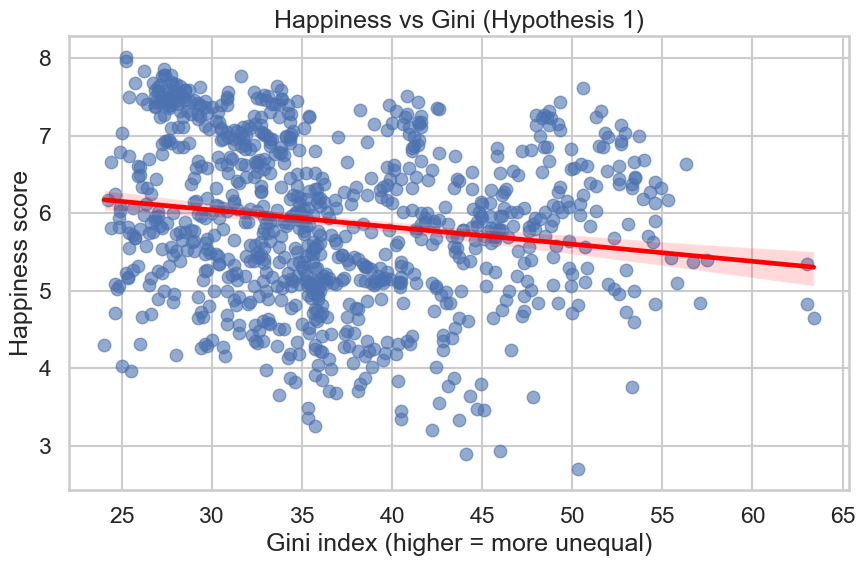

In [77]:
plt.figure(figsize=(9,6))
sns.regplot(
    data=h1_df,
    x="Gini",
    y="Happiness",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Happiness vs Gini (Hypothesis 1)")
plt.xlabel("Gini index (higher = more unequal)")
plt.ylabel("Happiness score")
plt.tight_layout()
plt.show()

##### Results:
* The overall pattern is downward‑sloping
* Gini Index increases, taht means more inequality
* Happiness scores tend to decrease
* The relationship is weak but consistent
* The confidence band shows uncertainty

##### Explanation:
The scatterplot of Happiness versus the Gini Index shows a weak but consistent negative relationship between income inequality and subjective well‑being. The regression line slopes downward, indicating that countries with higher inequality tend to report lower happiness scores. However, the points are widely dispersed around the trend line, suggesting that inequality explains only a small portion of the variation in happiness. This visual pattern aligns with the correlation results (Pearson r = −0.167, Spearman ρ = −0.208), both of which are statistically significant but small in magnitude. Overall, the plot supports Hypothesis 1 directionally: higher inequality is associated with lower happiness, though the strength of the relationship is modest.

##### 4. Simple regression model

##### Model:
$$ Happiness = 𝛽_0 + 𝛽_1 ⋅ Gini + 𝜀 $$

In [78]:
model_h1 = smf.ols("Happiness ~ Gini", data=h1_df).fit()
print(model_h1.summary())

                            OLS Regression Results                            
Dep. Variable:              Happiness   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     26.02
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           4.11e-07
Time:                        12:54:32   Log-Likelihood:                -1310.5
No. Observations:                 908   AIC:                             2625.
Df Residuals:                     906   BIC:                             2635.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.7053      0.163     41.153      0.0

##### Regression shows:
* Coefficient for Gini = - 0.0221
* R² = 0.028
* Confirms inequality has a weak relationship with happiness
* The effect is negative, statistically significant, but small

##### Explanation:
The regression shows that higher income inequality is associated with lower happiness, but the effect is small.
Although the negative coefficient is statistically significant, inequality explains only a small fraction of the differences in happiness across countries.
This means inequality matters, but it is far from the dominant factor shaping national well‑being.

##### Conclusion for Hypothesis 1
The results consistently show a weak but statistically significant negative relationship between inequality and happiness. Countries with higher Gini Index values tend to be slightly less happy, but inequality explains only a small portion of the differences in well‑being across nations. The idea that inequality has no effect on happiness is rejected (null hypothesis) and it is conclude that higher inequality is linked to slightly lower happiness, although the impact is small.

#### Hypothesis 2 — High vs Low Inequality Groups
This hypothesis tests whether countries with high inequality differ in happiness compared to countries with low inequality.
* H0: Mean happiness is the same in high‑inequality and low‑inequality countries.
* H1: Mean happiness differs between high‑inequality and low‑inequality countries.

In [79]:
# select only the indicators needed for Hypothesis 2
h2_df = analysis_df[["Happiness", "Gini"]].dropna()
h2_df.describe()

,Happiness,Gini
count,908.000000,908.000000
mean,5.892460,36.824780
std,1.039878,7.872061
min,2.694000,24.000000
25%,5.137500,30.800000
50%,5.885000,35.300000
75%,6.737000,42.050000
max,8.019000,63.400000


##### 1. Group Construction
* Countries were divided into two groups based on the median Gini Index:
* Low inequality group: countries with Gini values below the median
* High inequality group: countries with Gini values above the median
* This approach ensures balanced group sizes and allows for a straightforward comparison of mean happiness levels.

In [80]:
median_gini = h2_df["Gini"].median()
h2_df["Inequality_group"] = h2_df["Gini"].apply(
    lambda x: "Low inequality" if x < median_gini else "High inequality")
h2_df["Inequality_group"].value_counts()

Inequality_group
High inequality    455
Low inequality     453
Name: count, dtype: int64

##### 2.Independent samples T-test
* An independent samples T‑test was used to compare the mean happiness scores between the two groups.

In [81]:
low = h2_df[h2_df["Inequality_group"] == "Low inequality"]["Happiness"]
high = h2_df[h2_df["Inequality_group"] == "High inequality"]["Happiness"]

In [82]:
# welch t-test
t_stat, p_val = ttest_ind(low, high, equal_var=False)  
print("t-statistic:", t_stat)
print("p-value:", p_val)
print("Mean happiness (low inequality):", low.mean())
print("Mean happiness (high inequality):", high.mean())

t-statistic: 8.806564330309284
p-value: 6.478979552057949e-18
Mean happiness (low inequality): 6.184966887417218
Mean happiness (high inequality): 5.60123956043956


##### Explanation:
The independent samples t‑test revealed a highly significant difference in mean happiness between low‑inequality and high‑inequality countries. The low‑inequality group reported an average happiness score of 6.185, compared to 5.601 in the high‑inequality group. This difference of approximately 0.58 points is substantial in cross‑national well‑being research. The t‑statistic (t = 8.81) and extremely small p‑value (p < 0.001) indicate that this difference is not due to random variation. These results show that countries with lower income inequality tend to be meaningfully and consistently happier than those with higher inequality.

##### 3. ANOVA
* To explore the pattern more finely, countries were also divided into low, medium, and high inequality groups using tertiles.
* A one‑way ANOVA tested whether mean happiness differed across these three categories.

In [83]:
h2_df["Gini_group_3"] = pd.qcut(
    h2_df["Gini"], q=3, labels=["Low", "Medium", "High"])
groups = [
    h2_df[h2_df["Gini_group_3"] == "Low"]["Happiness"],
    h2_df[h2_df["Gini_group_3"] == "Medium"]["Happiness"],
    h2_df[h2_df["Gini_group_3"] == "High"]["Happiness"]]
f_stat, p_val = f_oneway(*groups)
print("ANOVA F:", f_stat)
print("p-value:", p_val)

ANOVA F: 38.919088241732204
p-value: 6.100552661639502e-17


##### Explanation:
The one‑way ANOVA comparing happiness across low, medium, and high inequality groups revealed a highly significant difference in mean happiness levels (F = 38.92, p < 0.001). This indicates that inequality categories capture meaningful variation in well‑being. The extremely small p‑value shows that the likelihood of these differences occurring by chance is virtually zero. Together with the t‑test results, the ANOVA confirms that countries with lower inequality tend to be substantially happier than those with medium or high inequality.

##### 4. Visual check

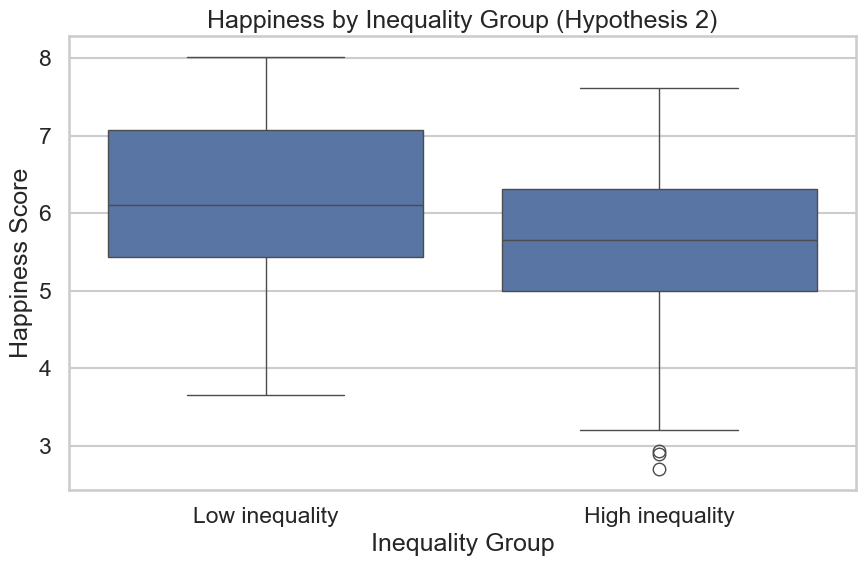

In [84]:
plt.figure(figsize=(9,6))
sns.boxplot(data=h2_df, x="Inequality_group", y="Happiness")
plt.title("Happiness by Inequality Group (Hypothesis 2)")
plt.xlabel("Inequality Group")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()

##### Results:
* Median happiness is higher in low‑inequality countries
* The spread of happiness is different across groups
* Overlap exists, but the groups are clearly distinct

##### Explanation:
The boxplot shows that countries with lower income inequality tend to be happier, with higher median happiness and less variation in well‑being. In contrast, high‑inequality countries not only have lower average happiness but also show greater instability and more extreme low values. This visual pattern strongly supports the statistical evidence that inequality levels are meaningfully associated with differences in national happiness.

##### Conclusion for Hypothesis 2
The results indicate that inequality categories are meaningfully associated with differences in national happiness. Countries with lower income inequality tend to be significantly happier than countries with higher inequality, and this difference is both statistically robust and practically meaningful. Therefore the null hypothesis is rejected and it is conclude that happiness levels differ across inequality groups, with lower inequality consistently associated with higher well‑being.